In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('ford.csv')
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (17966, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [2]:
df_scaled = df.copy()
numeric_columns = ['year', 'price', 'mileage', 'tax', 'mpg']
scaler = StandardScaler()
df_scaled[numeric_columns] = scaler.fit_transform(df[numeric_columns])

df_scaled.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,0.065128,-0.058959,Automatic,-0.380998,Petrol,0.591358,-0.020442,1.0
1,Focus,0.552866,0.362875,Manual,-0.733359,Petrol,0.591358,-0.020442,1.0
2,Focus,0.065128,0.151958,Manual,-0.560132,Petrol,0.591358,-0.020442,1.0
3,Fiesta,1.040605,1.101082,Manual,-0.662640,Petrol,0.510727,-1.738890,1.5
4,Fiesta,1.040605,0.890166,Automatic,-1.123724,Petrol,0.510727,-0.909294,1.0


In [3]:
import category_encoders as ce

print("Кардинальность категориальных признаков:")
print(f"model: {df['model'].nunique()} уникальных значений")
print(f"transmission: {df['transmission'].nunique()} уникальных значений")
print(f"fuelType: {df['fuelType'].nunique()} уникальных значений")

def encode_categorical_features(df):
    df_encoded = df.copy()
    
    target_encoder = ce.TargetEncoder(cols=['model'])
    df_encoded['model_encoded'] = target_encoder.fit_transform(df_encoded['model'], df_encoded['price'])
    
    transmission_encoded = pd.get_dummies(df_encoded['transmission'], prefix='transmission')
    df_encoded = pd.concat([df_encoded, transmission_encoded], axis=1)
    
    fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Hybrid': 2, 'Electric': 3, 'Other': 4}
    df_encoded['fuelType_encoded'] = df_encoded['fuelType'].map(fuel_mapping)
    
    df_encoded = df_encoded.drop(['model', 'transmission', 'fuelType'], axis=1)
    
    return df_encoded

df_encoded = encode_categorical_features(df_scaled)
print("Категориальные признаки закодированы")

df_encoded.head()

Кардинальность категориальных признаков:
model: 24 уникальных значений
transmission: 3 уникальных значений
fuelType: 5 уникальных значений
Категориальные признаки закодированы


,year,price,mileage,tax,mpg,engineSize,model_encoded,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_encoded
0,0.065128,-0.058959,-0.380998,0.591358,-0.020442,1.0,-0.439389,True,False,False,0
1,0.552866,0.362875,-0.733359,0.591358,-0.020442,1.0,0.191164,False,True,False,0
2,0.065128,0.151958,-0.560132,0.591358,-0.020442,1.0,0.191164,False,True,False,0
3,1.040605,1.101082,-0.662640,0.510727,-1.738890,1.5,-0.439389,False,True,False,0
4,1.040605,0.890166,-1.123724,0.510727,-0.909294,1.0,-0.439389,True,False,False,0


In [4]:
from sklearn.model_selection import train_test_split
x = df_encoded.drop('price', axis=1)
y = df_encoded['price']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_train = lr.predict(x_train)
y_pred_test = lr.predict(x_test)

def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name}:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")
    
    return mae, mse, r2

mae_train, rmse_train, r2_train = evaluate_model(y_train, y_pred_train, "Обучающая выборка")
mae_test, rmse_test, r2_test = evaluate_model(y_test, y_pred_test, "Тестовая выборка")


Обучающая выборка:
MAE: 0.3095
MSE: 0.4283
R²: 0.8167

Тестовая выборка:
MAE: 0.3085
MSE: 0.4146
R²: 0.8276


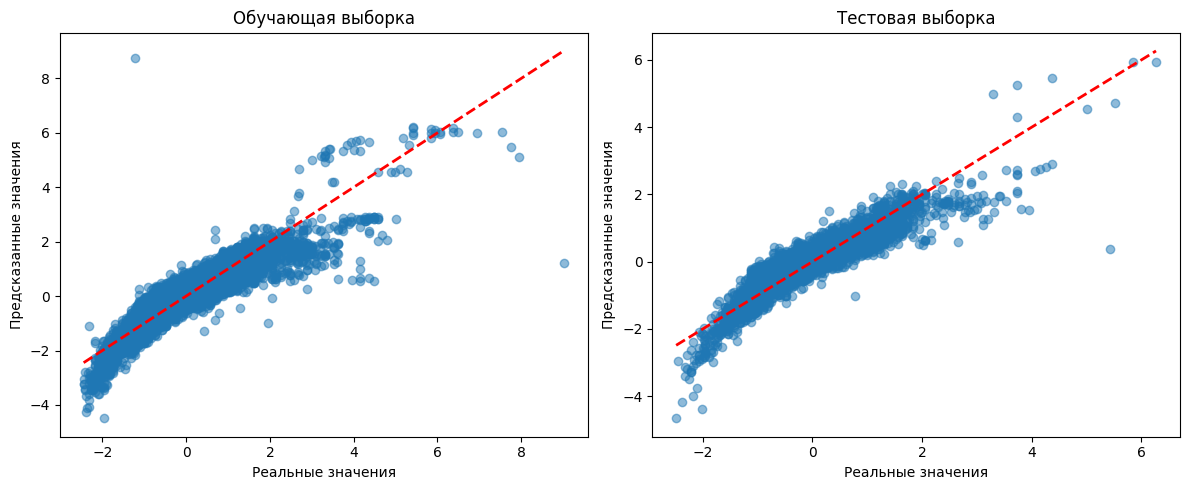

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Обучающая выборка')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Тестовая выборка')

plt.tight_layout()
plt.show()

In [7]:
print("\nАнализ переобучения/недообучения:")
print(f"Разница в R² между train и test: {r2_train - r2_test:.4f}")
print(f"Разница в MAE между train и test: {mae_train - mae_test:.4f}")
print(f"Разница в RMSE между train и test: {rmse_train - rmse_test:.4f}")

if r2_train > 0.9 and r2_test < 0.7:
    print("Вероятно, модель переобучена")
elif r2_train < 0.6 and r2_test < 0.6:
    print("Вероятно, модель недообучена")
else:
    print("Модель показывает сбалансированное качество")


Анализ переобучения/недообучения:
Разница в R² между train и test: -0.0109
Разница в MAE между train и test: 0.0011
Разница в RMSE между train и test: 0.0137
Модель показывает сбалансированное качество


In [8]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

def study_regularization(alphas, model_type='ridge'):
    results = []
    
    for alpha in alphas:
        if model_type == 'ridge':
            model = Ridge(alpha=alpha, random_state=42)
        elif model_type == 'lasso':
            model = Lasso(alpha=alpha, random_state=42)
        elif model_type == 'elasticnet':
            model = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=42)
        
        model.fit(x_train, y_train)
        y_pred_train = model.predict(x_train)
        y_pred_test = model.predict(x_test)
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'alpha': alpha,
            'r2_train': r2_train,
            'r2_test': r2_test
        })
    
    return pd.DataFrame(results)

ridge_results = study_regularization(alphas, 'ridge')
lasso_results = study_regularization(alphas, 'lasso')
elastic_results = study_regularization(alphas, 'elasticnet')

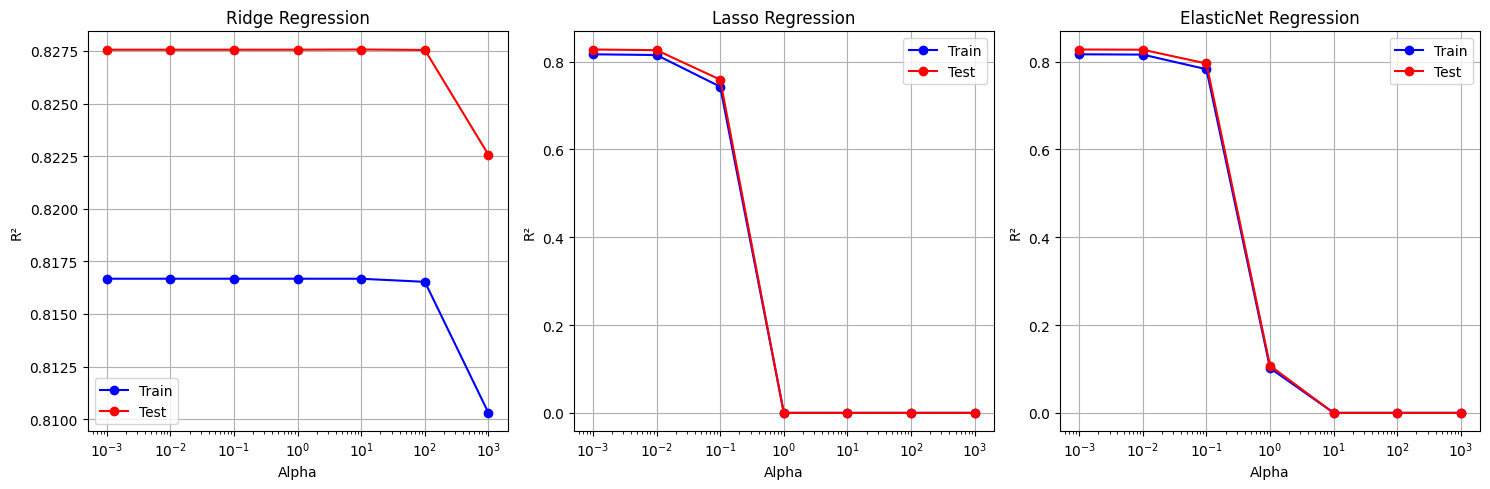

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.semilogx(ridge_results['alpha'], ridge_results['r2_train'], 'bo-', label='Train')
plt.semilogx(ridge_results['alpha'], ridge_results['r2_test'], 'ro-', label='Test')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Ridge Regression')
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.semilogx(lasso_results['alpha'], lasso_results['r2_train'], 'bo-', label='Train')
plt.semilogx(lasso_results['alpha'], lasso_results['r2_test'], 'ro-', label='Test')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Lasso Regression')
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.semilogx(elastic_results['alpha'], elastic_results['r2_train'], 'bo-', label='Train')
plt.semilogx(elastic_results['alpha'], elastic_results['r2_test'], 'ro-', label='Test')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('ElasticNet Regression')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [10]:
best_alpha_lasso = 0.1
lasso_best = Lasso(alpha=best_alpha_lasso, random_state=42)
lasso_best.fit(x_train, y_train)

coeffs = pd.DataFrame({
    'feature': x_train.columns,
    'coeff': lasso_best.coef_
}).sort_values('coeff', key=abs, ascending=False)

print("Коэффициенты Lasso модели:")
print(coeffs)

zeroed_features = coeffs[coeffs['coeff'] == 0]
print(f"\nЗануленные признаки ({len(zeroed_features)}):")
print(zeroed_features['feature'].tolist())

Коэффициенты Lasso модели:
                  feature     coeff
5           model_encoded  0.654173
0                    year  0.373183
1                 mileage -0.158246
3                     mpg -0.085237
2                     tax  0.000000
4              engineSize  0.000000
6  transmission_Automatic  0.000000
7     transmission_Manual -0.000000
8  transmission_Semi-Auto  0.000000
9        fuelType_encoded  0.000000

Зануленные признаки (6):
['tax', 'engineSize', 'transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_encoded']


In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

print(f"Исходное количество признаков: {x.shape[1]}")
print(f"После полиномиального преобразования: {x_poly.shape[1]}")

x_train_poly, x_test_poly, y_train, y_test = train_test_split(
    x_poly, y, test_size=0.2, random_state=42
)

ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(x_train_poly, y_train)

y_pred_poly_train = ridge_poly.predict(x_train_poly)
y_pred_poly_test = ridge_poly.predict(x_test_poly)

print("\nСРАВНЕНИЕ МОДЕЛЕЙ")

print("\n--- Линейная модель на исходных признаках ---")
evaluate_model(y_train, y_pred_train, "Обучающая выборка")
evaluate_model(y_test, y_pred_test, "Тестовая выборка")

print("\n--- Ridge на полиномиальных признаках ---") 
evaluate_model(y_train, y_pred_poly_train, "Обучающая выборка")
evaluate_model(y_test, y_pred_poly_test, "Тестовая выборка")

Исходное количество признаков: 10
После полиномиального преобразования: 65

СРАВНЕНИЕ МОДЕЛЕЙ

--- Линейная модель на исходных признаках ---

Обучающая выборка:
MAE: 0.3095
MSE: 0.4283
R²: 0.8167

Тестовая выборка:
MAE: 0.3085
MSE: 0.4146
R²: 0.8276

--- Ridge на полиномиальных признаках ---

Обучающая выборка:
MAE: 0.2543
MSE: 0.3444
R²: 0.8815

Тестовая выборка:
MAE: 0.2571
MSE: 0.3499
R²: 0.8772


(0.25708772554443693, np.float64(0.34985703512492017), 0.8772339442897128)

In [12]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('model', ElasticNet(random_state=42))
])

param_grid = {
    'poly__degree': [1, 2],
    'model__alpha': [0.001, 0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9] 
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший score (R²):", grid_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'model__alpha': 0.001, 'model__l1_ratio': 0.1, 'poly__degree': 1}
Лучший score (R²): 0.8139774118939791


In [15]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge_best': Ridge(alpha=0.001),
    'Lasso_best': Lasso(alpha=0.001),
    'ElasticNet_best': ElasticNet(alpha=0.001, l1_ratio=0.1),
    'Best_GridSearch': grid_search.best_estimator_
}

results = {}

for name, model in models.items():
    if name == 'Best_GridSearch':
        y_pred_train = model.predict(x_train)
        y_pred_test = model.predict(x_test)
    else:
        model.fit(x_train, y_train)
        y_pred_train = model.predict(x_train)
        y_pred_test = model.predict(x_test)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Test MAE': test_mae,
        'Difference R²': train_r2 - test_r2
    }

results_df = pd.DataFrame(results).T
print("\nСРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print(results_df.round(4))


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
                  Train R²  Test R²  Test MAE  Difference R²
LinearRegression    0.8167   0.8276    0.3085        -0.0109
Ridge_best          0.8167   0.8276    0.3085        -0.0109
Lasso_best          0.8166   0.8276    0.3084        -0.0109
ElasticNet_best     0.8167   0.8276    0.3085        -0.0109
Best_GridSearch     0.8167   0.8276    0.3085        -0.0109
